# ANADI – Trabalho Prático 2
## 4.1 Análise Exploratória de Dados (EDA)
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Analisar o impacto da eficiência energética na iluminação pública sobre a reserva de potência dos Postos de Transformação de Distribuição (PTD) e avaliar a viabilidade de instalação de carregadores de veículos elétricos.

---
## 1. Carregamento do Dataset

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('data/PTD_level_dataset.xlsx')
print('Dimensão do dataset:', df.shape)
print(f'Registos: {df.shape[0]:,} | Variáveis: {df.shape[1]}')

Dimensão do dataset: (72027, 32)
Registos: 72,027 | Variáveis: 32


In [82]:
# Primeiros registos
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,64.08,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,-13.20,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,173.10,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [83]:
# Informação geral: tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

In [84]:
# Sumário estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568


---
## 2. Exploração Visual dos Dados

### 2.1 Valores Omissos

                         Valores Omissos  Percentagem (%)
Pot_Geracao_kW                     70191            97.45
Geracao_per_Cliente                70191            97.45
PContratada_per_Cliente            21180            29.41
Pot_Contratada_kVA                 21180            29.41
D_PTD_LED                           3064             4.25
D_PTD                               3064             4.25
Util_Decimal                        3064             4.25
PFolga_PTD                          3064             4.25


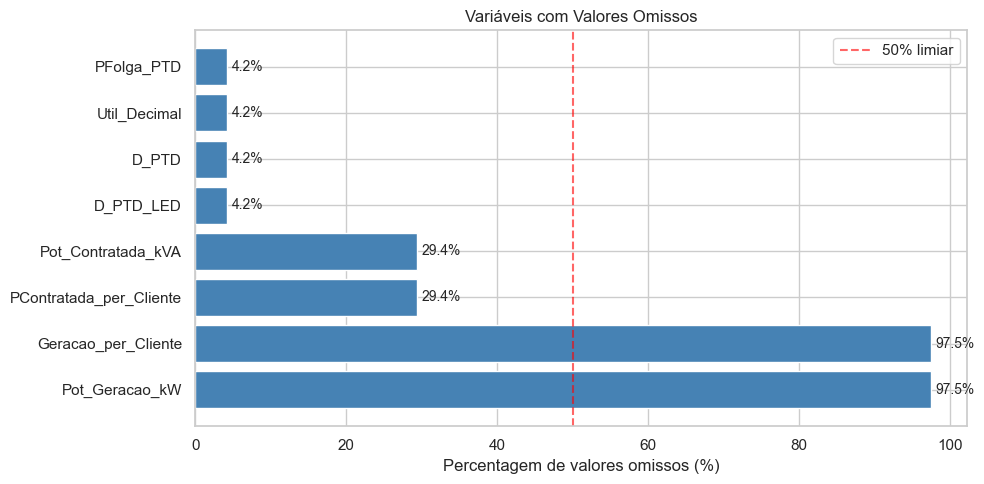

In [85]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Omissos': missing, 'Percentagem (%)': missing_pct})
missing_df = missing_df[missing_df['Valores Omissos'] > 0].sort_values('Percentagem (%)', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentagem (%)'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('Percentagem de valores omissos (%)')
ax.set_title('Variáveis com Valores Omissos')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% limiar')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Distribuição da Variável Categórica: Tipo Construtivo

C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\1570791492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0], palette='Blues_r')


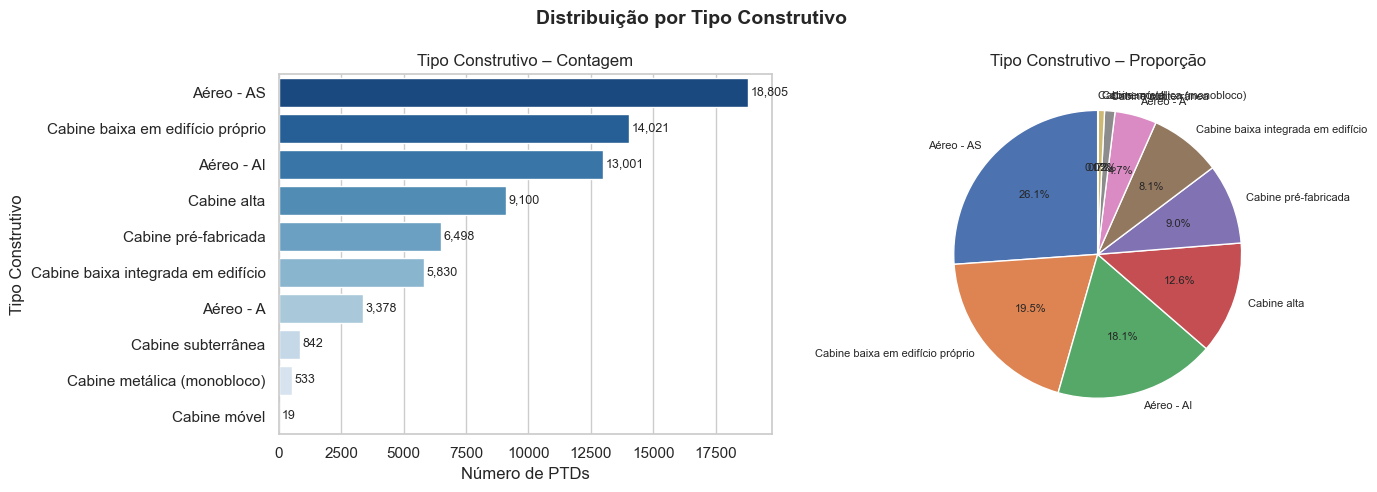

In [86]:
tipo_counts = df['Tipo Construtivo'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_xlabel('Número de PTDs')
axes[0].set_title('Tipo Construtivo – Contagem')
for i, v in enumerate(tipo_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Gráfico circular
axes[1].pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Tipo Construtivo – Proporção')

plt.suptitle('Distribuição por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Distribuição do Nível de Utilização dos PTDs

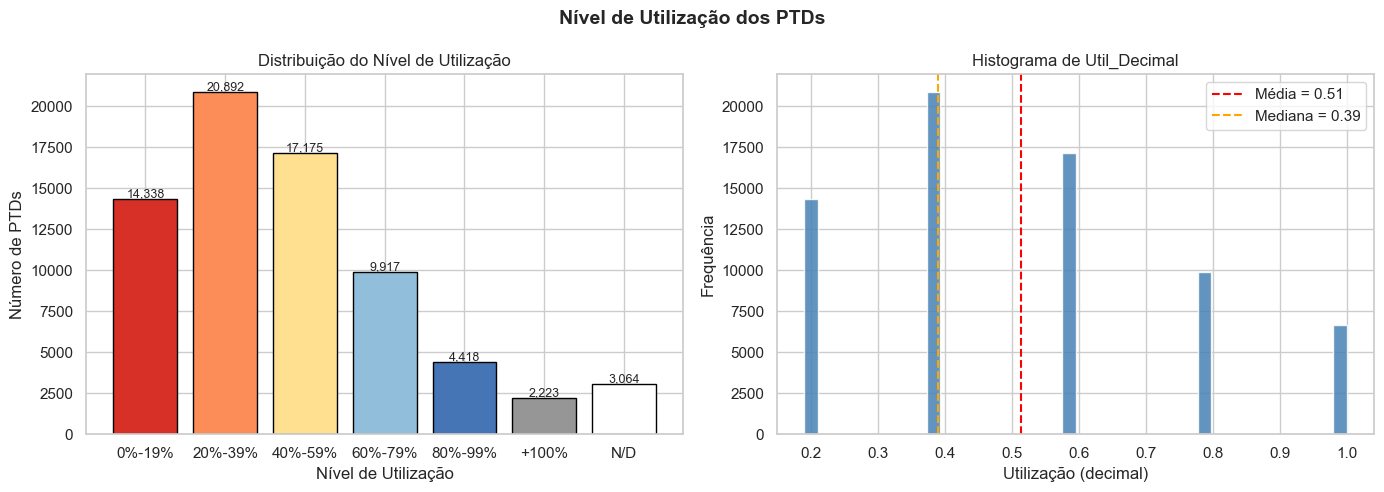

PTDs com utilização acima de 80%: 6,641 (9.6%)
PTDs com utilização acima de 100%: 2,223 (3.2%)


In [87]:
util_col = [c for c in df.columns if 'Utiliza' in c][0]
util_counts = df[util_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por categoria
cores = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4', '#969696', '#ffffff']
cats_order = ['0%-19%', '20%-39%', '40%-59%', '60%-79%', '80%-99%', '+100%', 'N/D']
ordered = [util_counts.get(c, 0) for c in cats_order]
axes[0].bar(cats_order, ordered, color=cores[:len(cats_order)], edgecolor='black')
axes[0].set_xlabel('Nível de Utilização')
axes[0].set_ylabel('Número de PTDs')
axes[0].set_title('Distribuição do Nível de Utilização')
for i, v in enumerate(ordered):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Histograma de Util_Decimal (excluindo N/D)
util_dec = df['Util_Decimal'].dropna()
axes[1].hist(util_dec, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(util_dec.mean(), color='red', linestyle='--', label=f'Média = {util_dec.mean():.2f}')
axes[1].axvline(util_dec.median(), color='orange', linestyle='--', label=f'Mediana = {util_dec.median():.2f}')
axes[1].set_xlabel('Utilização (decimal)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Util_Decimal')
axes[1].legend()

plt.suptitle('Nível de Utilização dos PTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PTDs com utilização acima de 80%: {(util_dec >= 0.8).sum():,} ({(util_dec >= 0.8).mean()*100:.1f}%)')
print(f'PTDs com utilização acima de 100%: {(util_dec >= 1.0).sum():,} ({(util_dec >= 1.0).mean()*100:.1f}%)')

### 2.4 Distribuição das Variáveis Numéricas Principais

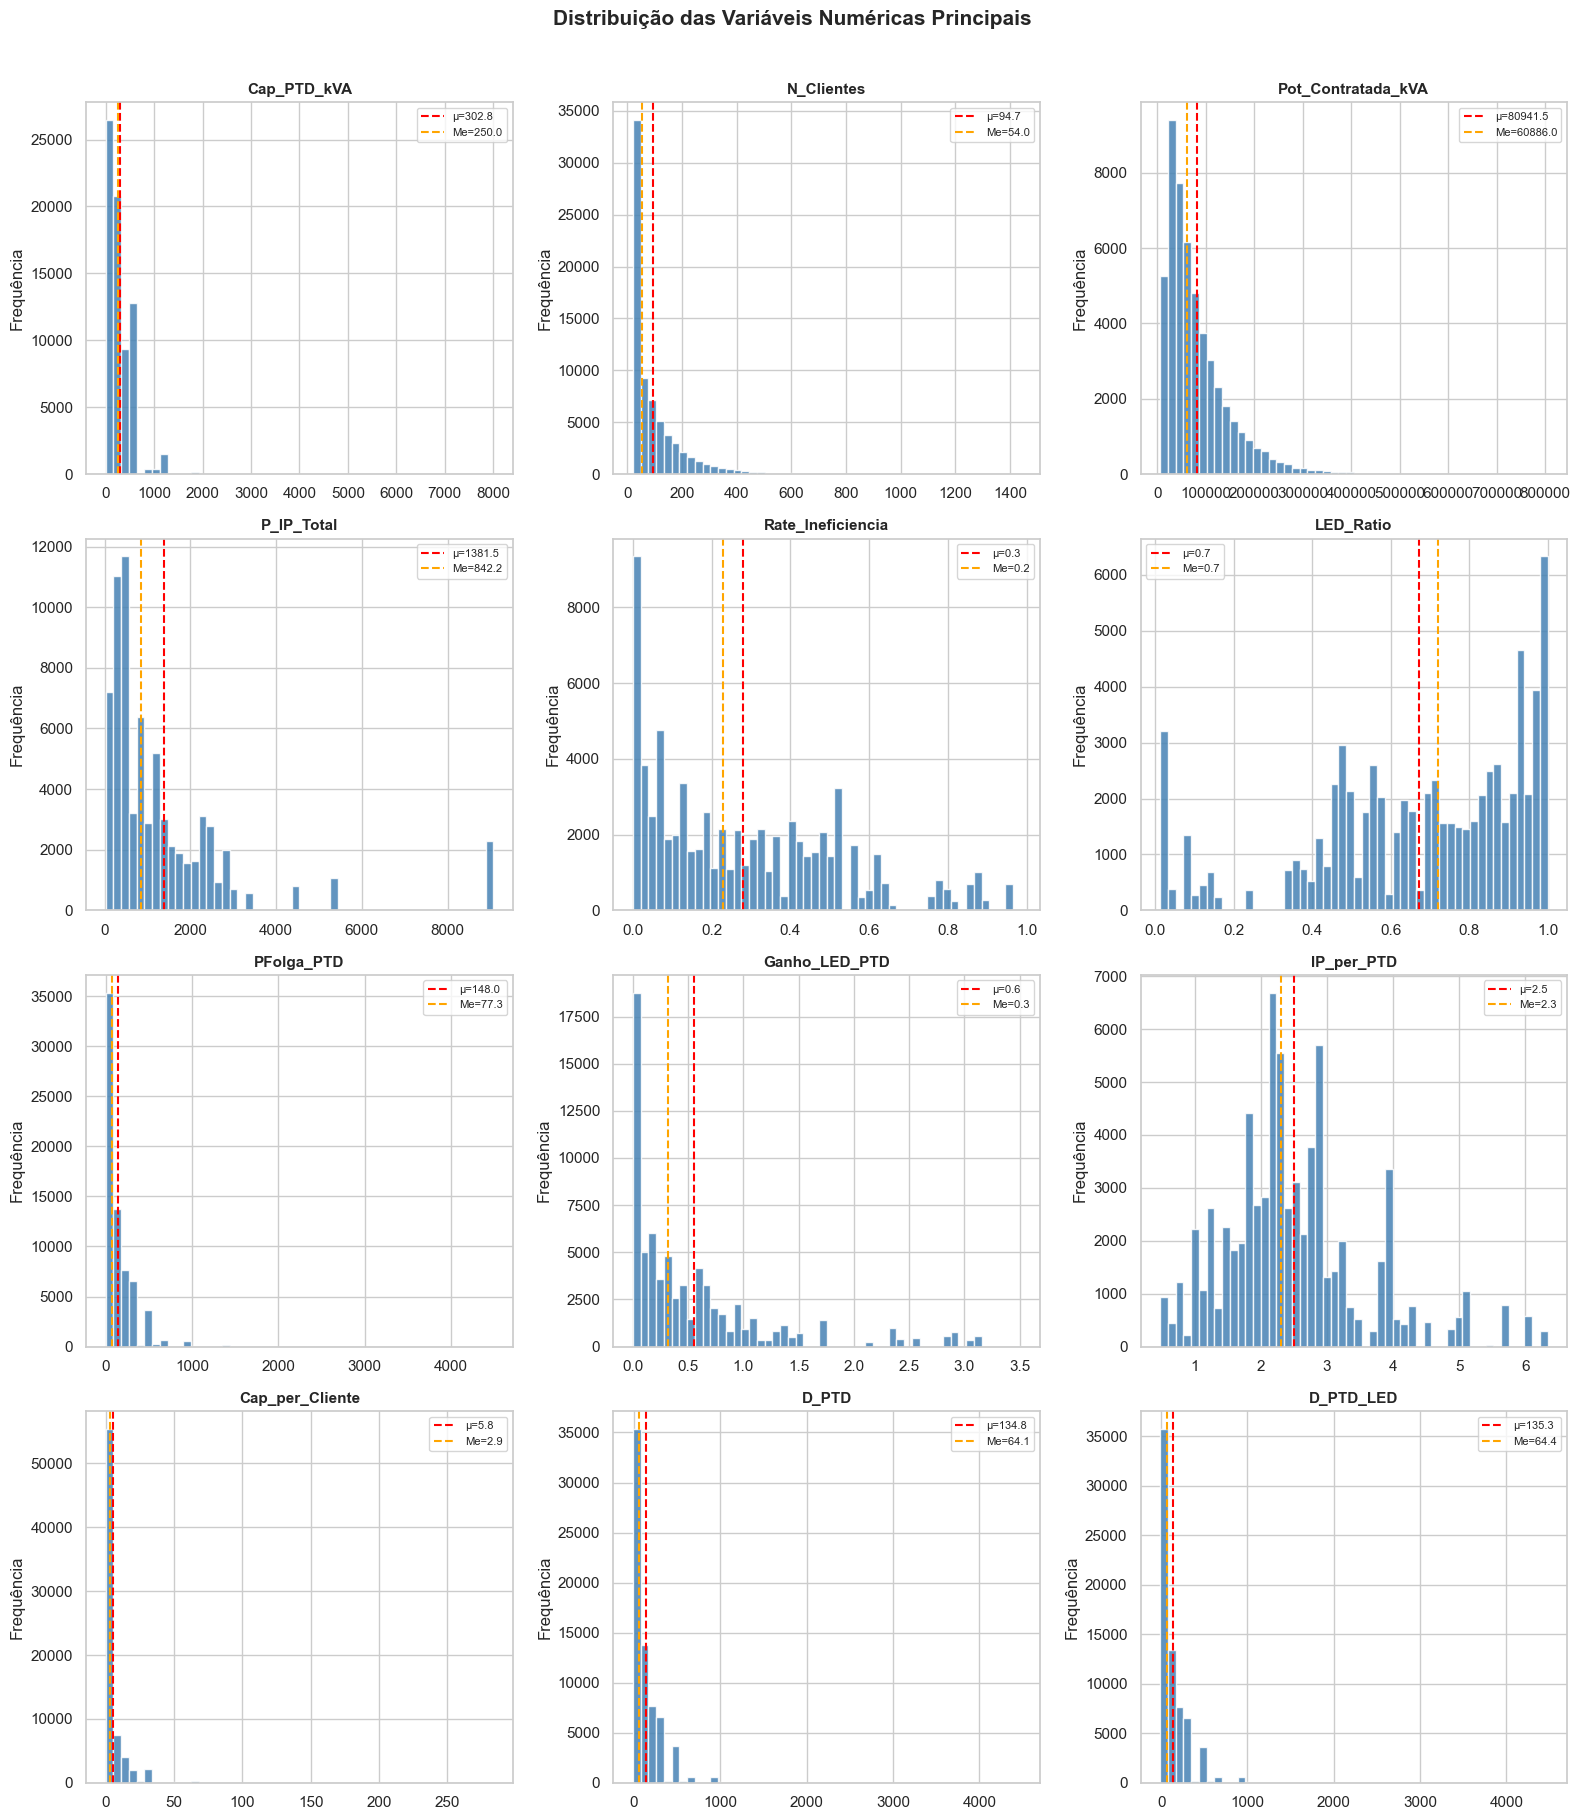

In [88]:
vars_principais = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'PFolga_PTD', 'Ganho_LED_PTD', 'IP_per_PTD',
    'Cap_per_Cliente', 'D_PTD', 'D_PTD_LED'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Me={data.median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Boxplots por Tipo Construtivo

C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

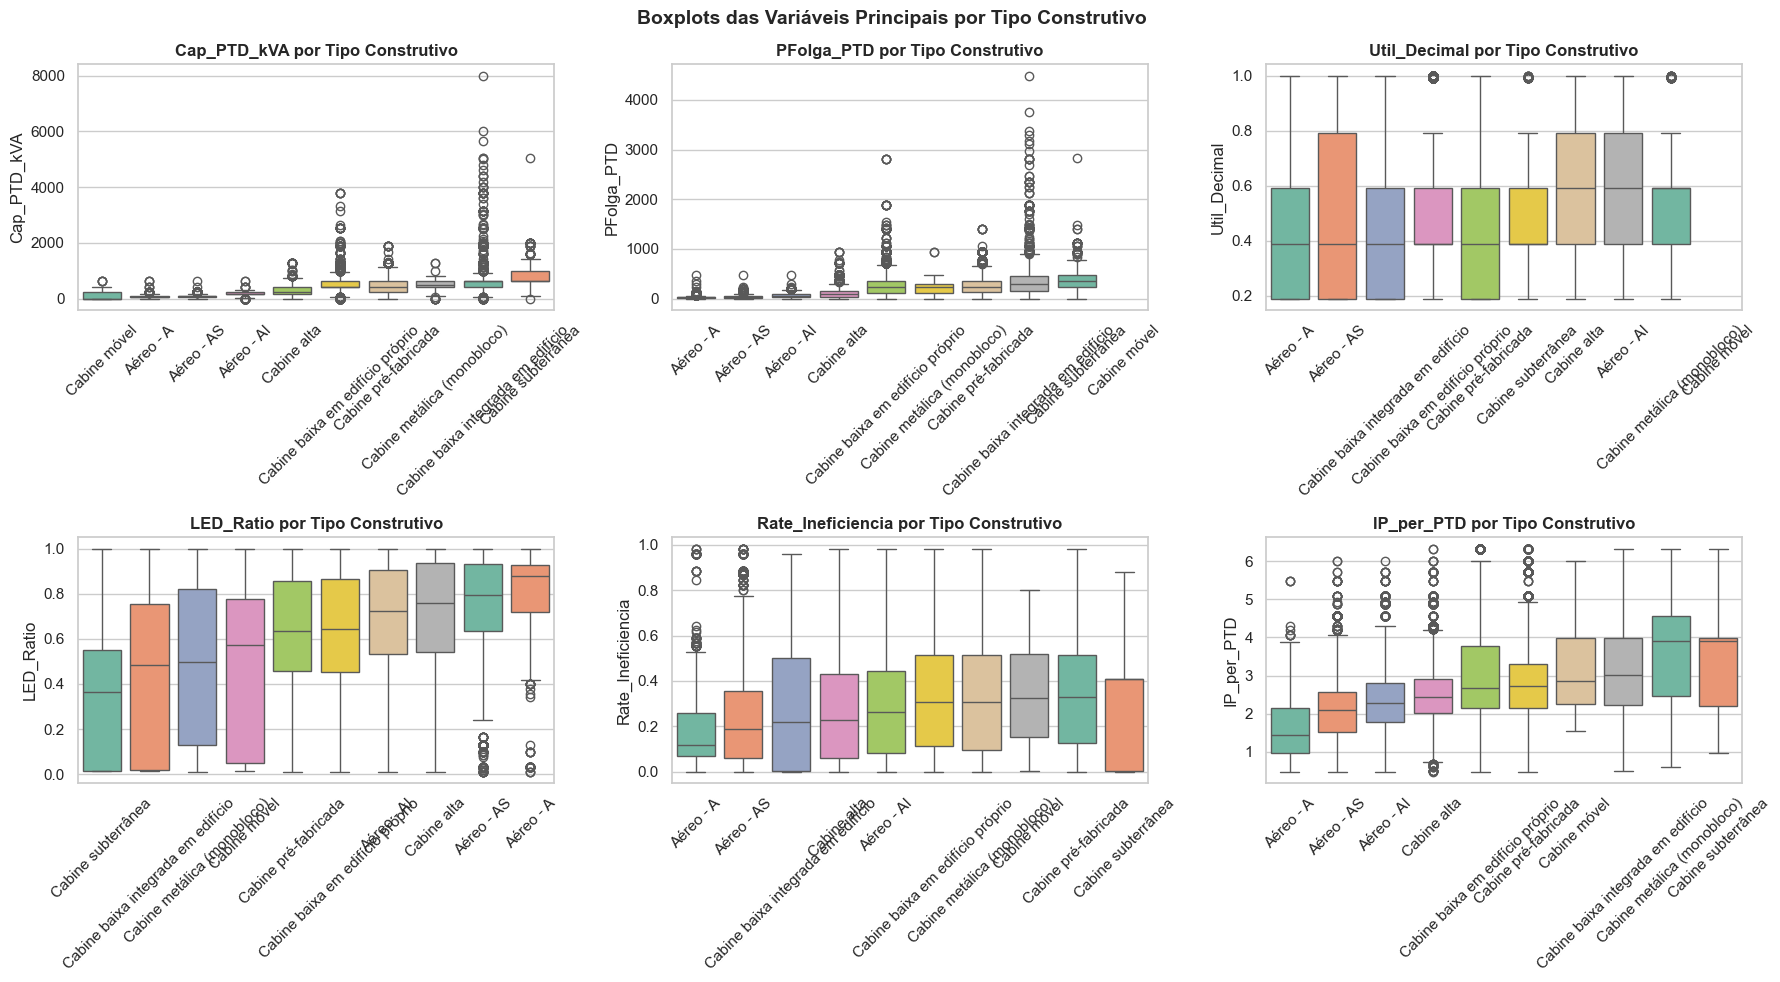

In [89]:
vars_boxplot = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio', 'Rate_Ineficiencia', 'IP_per_PTD']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    sns.boxplot(
        data=df, x='Tipo Construtivo', y=col,
        ax=axes[i], palette='Set2',
        order=df.groupby('Tipo Construtivo')[col].median().sort_values().index
    )
    axes[i].set_title(f'{col} por Tipo Construtivo', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Boxplots das Variáveis Principais por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Matriz de Correlação

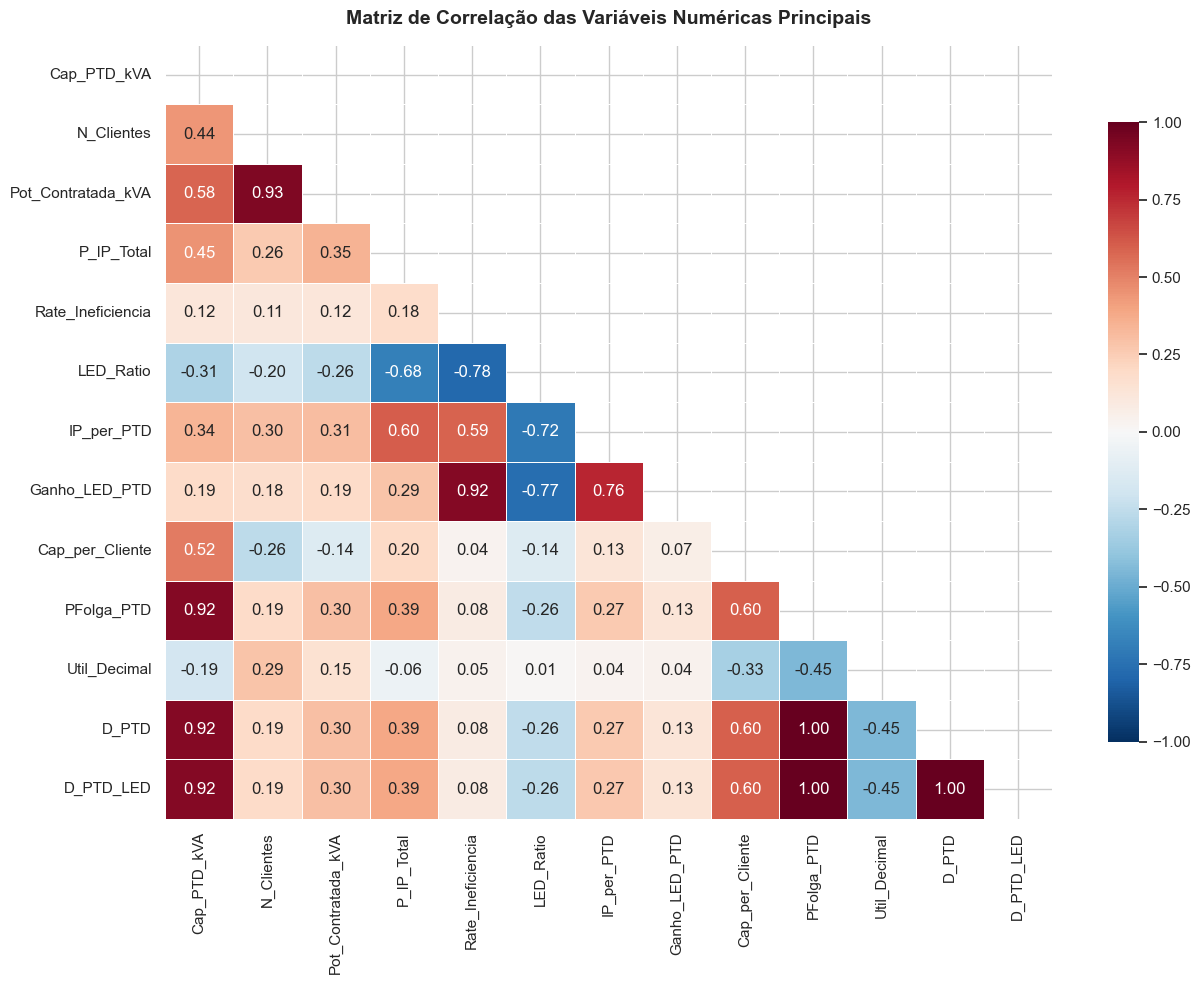

In [90]:
vars_corr = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente',
    'PFolga_PTD', 'Util_Decimal', 'D_PTD', 'D_PTD_LED'
]

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação das Variáveis Numéricas Principais', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.7 Relações-Chave entre Variáveis

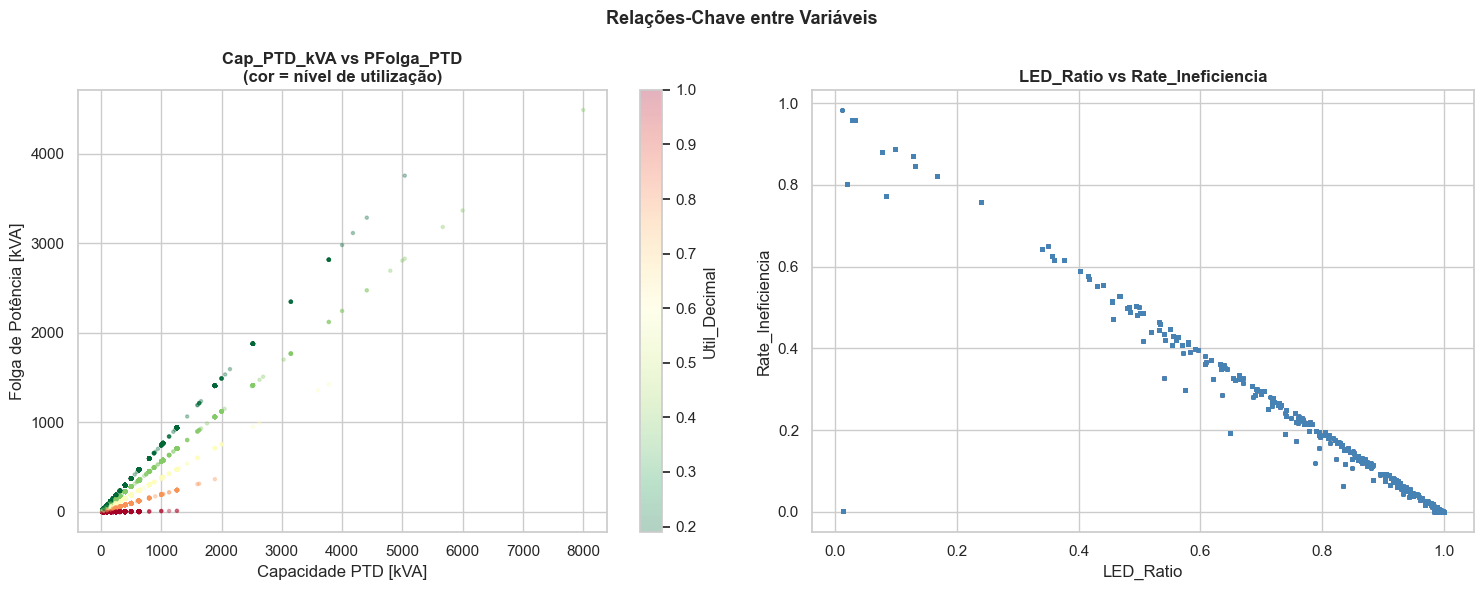

In [91]:
# Folga de Potência vs Capacidade do PTD — colorido por Tipo Construtivo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_data = df[['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio',
                    'Rate_Ineficiencia', 'Tipo Construtivo']].dropna()

# Scatter: Cap_PTD_kVA vs PFolga_PTD
sc1 = axes[0].scatter(
    scatter_data['Cap_PTD_kVA'], scatter_data['PFolga_PTD'],
    c=scatter_data['Util_Decimal'], cmap='RdYlGn_r',
    alpha=0.3, s=5
)
plt.colorbar(sc1, ax=axes[0], label='Util_Decimal')
axes[0].set_xlabel('Capacidade PTD [kVA]')
axes[0].set_ylabel('Folga de Potência [kVA]')
axes[0].set_title('Cap_PTD_kVA vs PFolga_PTD\n(cor = nível de utilização)', fontweight='bold')

# Scatter: LED_Ratio vs Rate_Ineficiencia
sc2 = axes[1].scatter(
    scatter_data['LED_Ratio'], scatter_data['Rate_Ineficiencia'],
    alpha=0.2, s=5, color='steelblue'
)
axes[1].set_xlabel('LED_Ratio')
axes[1].set_ylabel('Rate_Ineficiencia')
axes[1].set_title('LED_Ratio vs Rate_Ineficiencia', fontweight='bold')

plt.suptitle('Relações-Chave entre Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

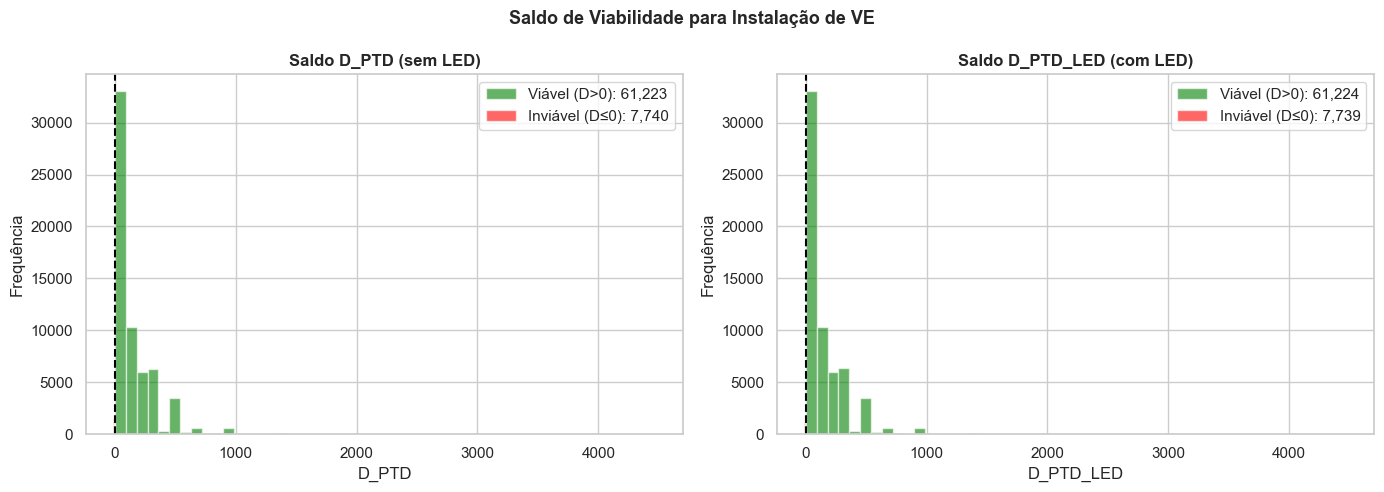

PTDs viáveis SEM LED:  61,223 / 68,963 (88.8%)
PTDs viáveis COM LED:  61,224 / 68,963 (88.8%)


In [92]:
# Distribuição de D_PTD e D_PTD_LED — Viabilidade de VE
d_data = df[['D_PTD', 'D_PTD_LED']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['D_PTD', 'D_PTD_LED'],
                           ['Saldo D_PTD (sem LED)', 'Saldo D_PTD_LED (com LED)']):
    data = d_data[col]
    pos = (data > 0).sum()
    neg = (data <= 0).sum()
    ax.hist(data[data > 0], bins=50, color='green', alpha=0.6, label=f'Viável (D>0): {pos:,}')
    ax.hist(data[data <= 0], bins=30, color='red', alpha=0.6, label=f'Inviável (D≤0): {neg:,}')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Saldo de Viabilidade para Instalação de VE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total = len(d_data)
print(f'PTDs viáveis SEM LED:  {(d_data["D_PTD"] > 0).sum():,} / {total:,} ({(d_data["D_PTD"] > 0).mean()*100:.1f}%)')
print(f'PTDs viáveis COM LED:  {(d_data["D_PTD_LED"] > 0).sum():,} / {total:,} ({(d_data["D_PTD_LED"] > 0).mean()*100:.1f}%)')

---
## 3. Pré-processamento dos Dados
### 3.1 Tratamento de Valores Omissos

In [93]:
df_clean = df.copy()

# Pot_Geracao_kW e Geracao_per_Cliente: ~97% de valores omissos → remover colunas
cols_drop_missing = ['Pot_Geracao_kW', 'Geracao_per_Cliente']
df_clean.drop(columns=cols_drop_missing, inplace=True)
print(f'Colunas removidas por excesso de valores omissos (>95%): {cols_drop_missing}')

# Nível de Utilização com valor "N/D" corresponde às mesmas linhas com PFolga_PTD = NaN
# Remover registos sem PFolga_PTD (não é possível calcular métricas principais)
n_antes = len(df_clean)
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)
print(f'Registos removidos (PFolga_PTD/Util indefinido): {n_antes - len(df_clean):,}')
print(f'Registos restantes: {len(df_clean):,}')

# Pot_Contratada_kVA: ~29% de valores omissos → imputar com mediana por Tipo Construtivo
df_clean['Pot_Contratada_kVA'] = df_clean.groupby('Tipo Construtivo')['Pot_Contratada_kVA'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['PContratada_per_Cliente'] = df_clean.groupby('Tipo Construtivo')['PContratada_per_Cliente'].transform(
    lambda x: x.fillna(x.median())
)
print(f'\nValores omissos restantes:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Colunas removidas por excesso de valores omissos (>95%): ['Pot_Geracao_kW', 'Geracao_per_Cliente']
Registos removidos (PFolga_PTD/Util indefinido): 3,064
Registos restantes: 68,963

Valores omissos restantes:
Series([], dtype: int64)


### 3.2 Transformação de Variáveis Categóricas

In [94]:
# Tipo Construtivo → Label Encoding (ordenado por mediana de Cap_PTD_kVA)
le = LabelEncoder()
df_clean['Tipo_Construtivo_Enc'] = le.fit_transform(df_clean['Tipo Construtivo'])

mapeamento = pd.DataFrame({'Categoria': le.classes_,
                            'Código': range(len(le.classes_))})
print('Mapeamento Label Encoding – Tipo Construtivo:')
print(mapeamento.to_string(index=False))

# Nível de Utilização [%] → já existe Util_Decimal (variável numérica equivalente)
# Criar também variável binária de saturação (>=80%)
df_clean['PTD_Saturado'] = (df_clean['Util_Decimal'] >= 0.8).astype(int)
print(f'\nPTDs saturados (≥80%): {df_clean["PTD_Saturado"].sum():,} ({df_clean["PTD_Saturado"].mean()*100:.1f}%)')

Mapeamento Label Encoding – Tipo Construtivo:
                         Categoria  Código
                         Aéreo - A       0
                        Aéreo - AI       1
                        Aéreo - AS       2
                       Cabine alta       3
  Cabine baixa em edifício próprio       4
Cabine baixa integrada em edifício       5
       Cabine metálica (monobloco)       6
              Cabine pré-fabricada       7
                Cabine subterrânea       8

PTDs saturados (≥80%): 6,641 (9.6%)


### 3.3 Seleção de Variáveis Relevantes

In [95]:
# Variáveis removidas e justificação:
# - Identificadores (sem valor preditivo): Distrito, Concelho, CodDistritoConcelho,
#   Código de Instalação, Coordenadas Geográficas
# - Redundante: 'Potência instalada [kVA]' == Cap_PTD_kVA (correlação perfeita)
# - Redundante: Nível de Utilização [%] → substituída por Util_Decimal
# - Constante: PVE_PTD (único valor = 13.2 kW para todos os registos)
# - Administrativa: N_PTDs_Concelho (não caracteriza o PTD individualmente)
# - N_Clientes_Produtores: maioritariamente zero, sem variabilidade útil
# - Clientes_Produtores_Ratio: derivada da anterior
# - N_Luminarias / N_Lampadas: informação já capturada em P_IP_Total e LED_Ratio
# - IP_Inef_per_PTD / P_IP_Inef: colinear com IP_per_PTD × Rate_Ineficiencia
# - Tipo Construtivo (texto): substituída por Tipo_Construtivo_Enc

pot_col   = [c for c in df_clean.columns if 'instalada' in c][0]
util_col_str = [c for c in df_clean.columns if 'Utiliza' in c][0]
cod_col   = [c for c in df_clean.columns if 'digo' in c][0]
coord_col = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Distrito', 'Concelho', 'CodDistritoConcelho',
    cod_col, coord_col,
    pot_col, util_col_str,
    'PVE_PTD', 'N_PTDs_Concelho',
    'N_Clientes_Produtores', 'Clientes_Produtores_Ratio',
    'N_Luminarias', 'N_Lampadas',
    'IP_Inef_per_PTD', 'P_IP_Inef',
    'Tipo Construtivo'
]

# Remover apenas as colunas que existem no dataframe
cols_remover_existentes = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_remover_existentes)

print('Variáveis selecionadas para modelação:')
for c in df_model.columns:
    print(f'  {c:<35} dtype={df_model[c].dtype}')
print(f'\nTotal de variáveis: {df_model.shape[1]}')

Variáveis selecionadas para modelação:
  Cap_PTD_kVA                         dtype=int64
  Pot_Contratada_kVA                  dtype=float64
  N_Clientes                          dtype=int64
  P_IP_Total                          dtype=float64
  Rate_Ineficiencia                   dtype=float64
  LED_Ratio                           dtype=float64
  D_PTD                               dtype=float64
  IP_per_PTD                          dtype=float64
  Ganho_LED_PTD                       dtype=float64
  D_PTD_LED                           dtype=float64
  Cap_per_Cliente                     dtype=float64
  PContratada_per_Cliente             dtype=float64
  Util_Decimal                        dtype=float64
  PFolga_PTD                          dtype=float64
  Tipo_Construtivo_Enc                dtype=int64
  PTD_Saturado                        dtype=int64

Total de variáveis: 16


### 3.4 Normalização / Standardização

In [96]:
# Variáveis binárias / ordinais não são normalizadas
cols_nao_normalizar = ['Tipo_Construtivo_Enc', 'PTD_Saturado']
cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns
                  if c not in cols_nao_normalizar]

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df_model[cols_numericas])

print('Variáveis normalizadas (StandardScaler):')
print(cols_numericas)
print(f'\nEstatísticas após normalização (devem ter μ≈0, σ≈1):')
print(df_scaled[cols_numericas].describe().loc[['mean', 'std']].round(4).T)

Variáveis normalizadas (StandardScaler):
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio', 'D_PTD', 'IP_per_PTD', 'Ganho_LED_PTD', 'D_PTD_LED', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Util_Decimal', 'PFolga_PTD']

Estatísticas após normalização (devem ter μ≈0, σ≈1):
                         mean  std
Cap_PTD_kVA               0.0  1.0
Pot_Contratada_kVA        0.0  1.0
N_Clientes               -0.0  1.0
P_IP_Total                0.0  1.0
Rate_Ineficiencia        -0.0  1.0
LED_Ratio                -0.0  1.0
D_PTD                     0.0  1.0
IP_per_PTD               -0.0  1.0
Ganho_LED_PTD             0.0  1.0
D_PTD_LED                 0.0  1.0
Cap_per_Cliente           0.0  1.0
PContratada_per_Cliente  -0.0  1.0
Util_Decimal             -0.0  1.0
PFolga_PTD                0.0  1.0


---
## 4. Sumário Final do Dataset Pré-processado

In [97]:
print('=' * 55)
print('       RESUMO DO PRÉ-PROCESSAMENTO')
print('=' * 55)
print(f'Dataset original:     {df.shape[0]:>7,} registos × {df.shape[1]:>2} variáveis')
print(f'Após remoção de NaN:  {df_model.shape[0]:>7,} registos × {df_model.shape[1]:>2} variáveis')
print(f'Registos removidos:   {df.shape[0] - df_model.shape[0]:>7,}')
print(f'Variáveis removidas:  {df.shape[1] - df_model.shape[1]:>7}')
print(f'Valores omissos rem.: {df_model.isnull().sum().sum()}')
print('=' * 55)
print(f'\nVariáveis finais ({df_model.shape[1]}):')
grupos = {
    'PTD (nível posto)': ['Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA', 'Tipo_Construtivo_Enc'],
    'Iluminação Pública (concelho)': ['P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio'],
    'Variáveis derivadas': ['PFolga_PTD', 'Cap_per_Cliente', 'IP_per_PTD',
                             'Ganho_LED_PTD', 'D_PTD', 'D_PTD_LED',
                             'Util_Decimal', 'PContratada_per_Cliente', 'PTD_Saturado']
}
for grupo, cols in grupos.items():
    existentes = [c for c in cols if c in df_model.columns]
    print(f'  [{grupo}]: {existentes}')

print(f'\nDataset para modelação (df_model): {df_model.shape}')
print(f'Dataset normalizado (df_scaled):   {df_scaled.shape}')

       RESUMO DO PRÉ-PROCESSAMENTO
Dataset original:      72,027 registos × 32 variáveis
Após remoção de NaN:   68,963 registos × 16 variáveis
Registos removidos:     3,064
Variáveis removidas:       16
Valores omissos rem.: 0

Variáveis finais (16):
  [PTD (nível posto)]: ['Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA', 'Tipo_Construtivo_Enc']
  [Iluminação Pública (concelho)]: ['P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio']
  [Variáveis derivadas]: ['PFolga_PTD', 'Cap_per_Cliente', 'IP_per_PTD', 'Ganho_LED_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PContratada_per_Cliente', 'PTD_Saturado']

Dataset para modelação (df_model): (68963, 16)
Dataset normalizado (df_scaled):   (68963, 16)


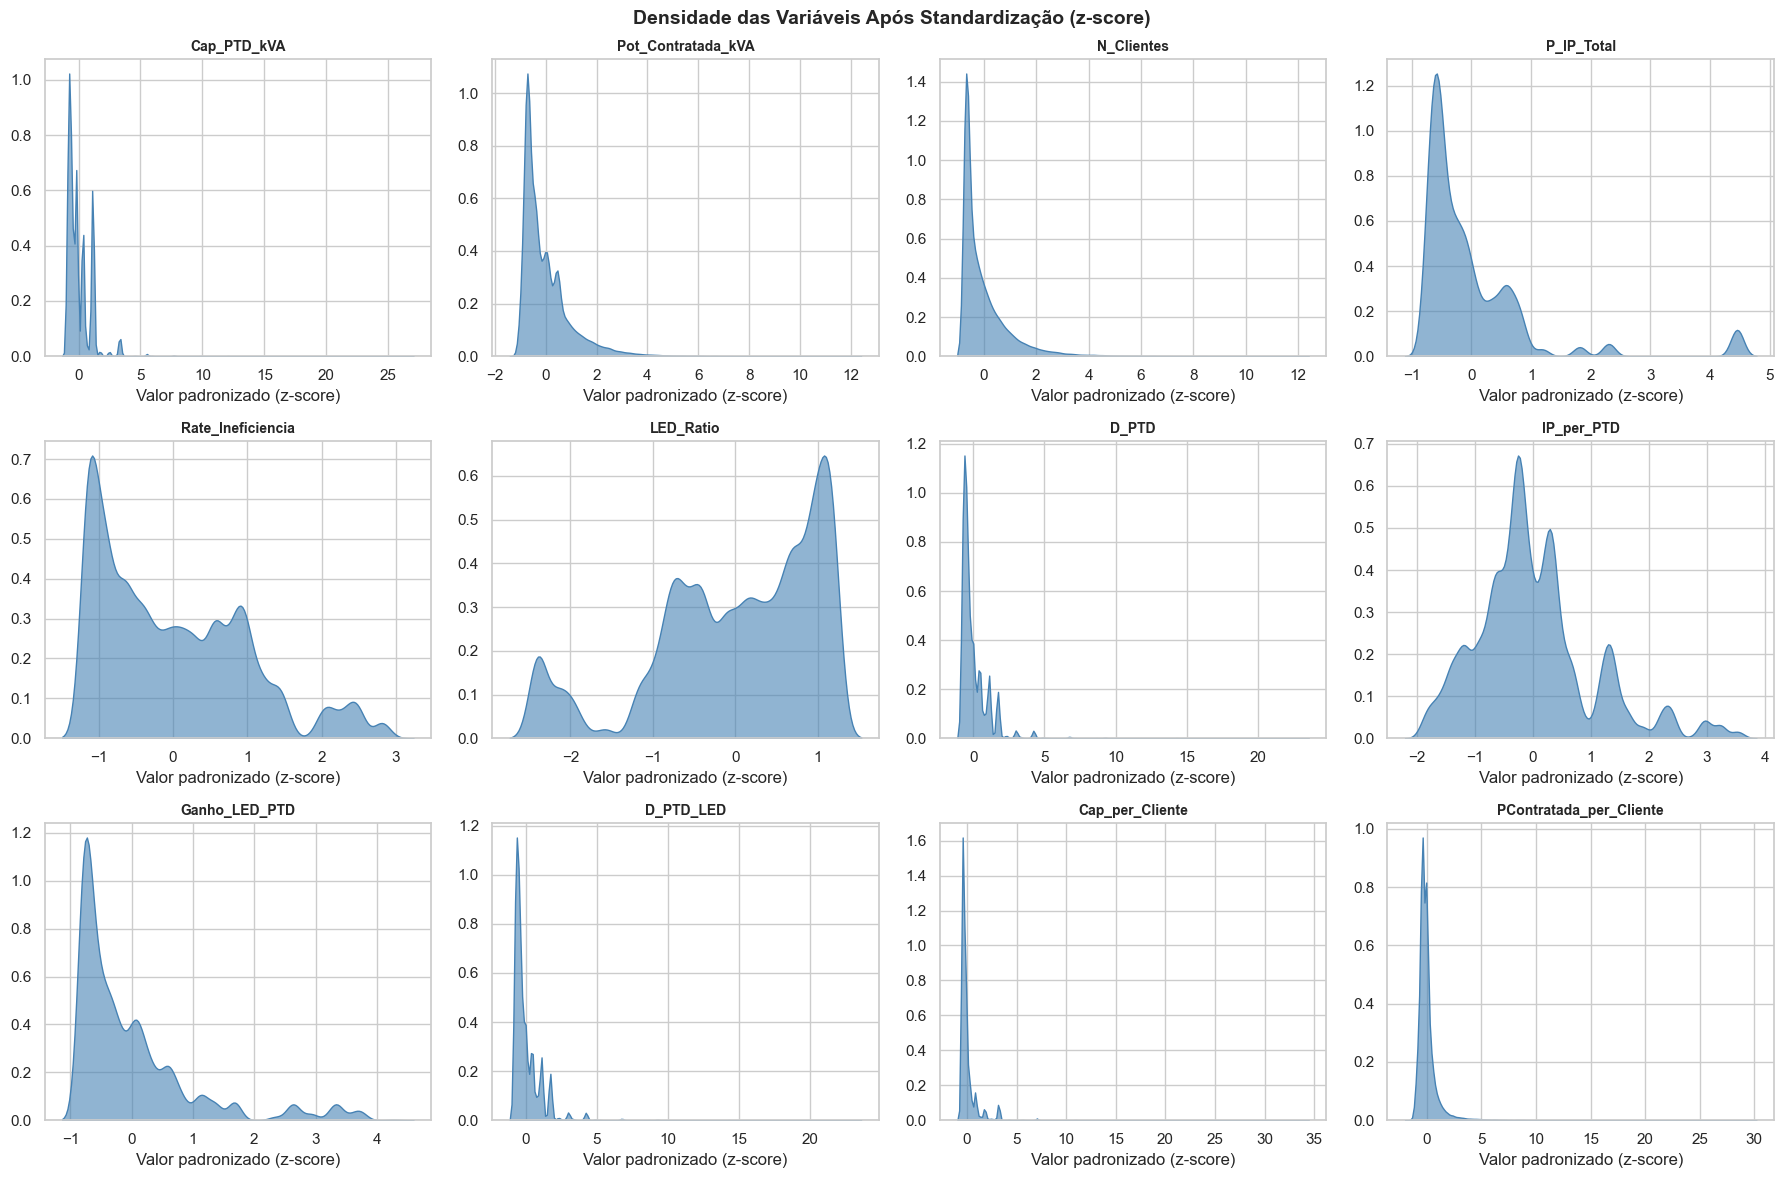

In [98]:
# Visualização final: distribuição das variáveis após standardização
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

cols_plot = [c for c in cols_numericas[:12]]
for i, col in enumerate(cols_plot):
    sns.kdeplot(df_scaled[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor padronizado (z-score)')
    axes[i].set_ylabel('')

for j in range(len(cols_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Densidade das Variáveis Após Standardização (z-score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4.2 Regressão — Previsão de PFolga_PTD

O objetivo é prever a **Folga de Potência por PTD** (`PFolga_PTD`), variável contínua que determina a capacidade de um PTD em absorver mobilidade elétrica.

> **Nota:** `D_PTD`, `D_PTD_LED` e `Util_Decimal` são excluídos das features por serem derivados diretamente de `PFolga_PTD` — incluí-los causaria data leakage.

### 4.2.1 Diagrama de Correlação com PFolga_PTD

Correlação de Pearson com PFolga_PTD:
Cap_PTD_kVA                0.9159
Cap_per_Cliente            0.5996
Tipo_Construtivo_Enc       0.5198
P_IP_Total                 0.3884
Pot_Contratada_kVA         0.3472
PContratada_per_Cliente    0.3160
IP_per_PTD                 0.2655
LED_Ratio                 -0.2573
N_Clientes                 0.1880
Ganho_LED_PTD              0.1295
Rate_Ineficiencia          0.0786


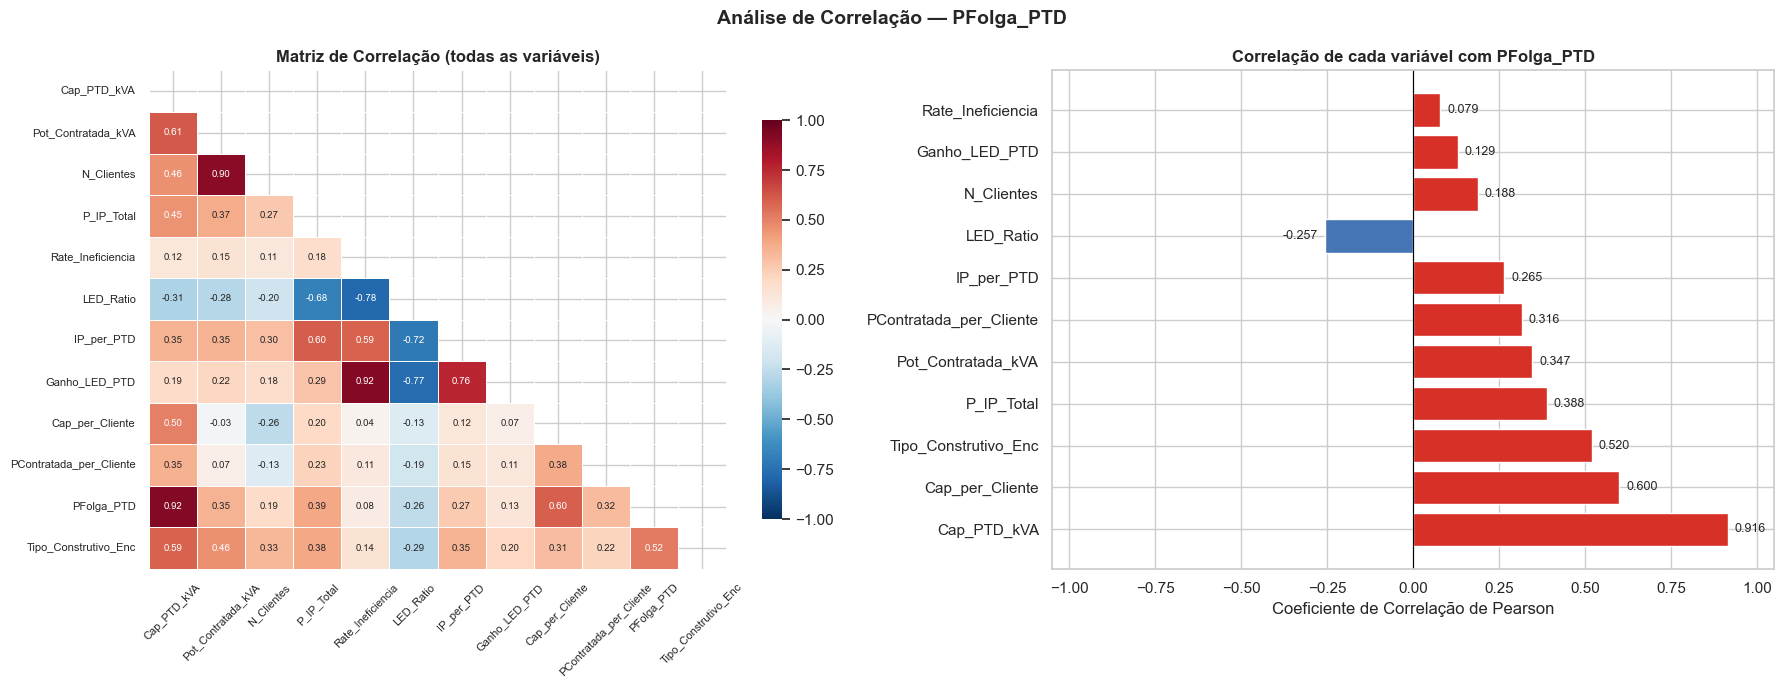


Variável mais correlacionada: Cap_PTD_kVA (r = 0.9159)


In [99]:
# Variáveis excluídas por data leakage ou por serem binárias/ordinais sem sentido de correlação linear
LEAKAGE = ['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PTD_Saturado']
TARGET = 'PFolga_PTD'

corr_cols = [c for c in df_model.columns if c not in LEAKAGE]
corr_df = df_model[corr_cols].dropna()

# Correlação de Pearson com PFolga_PTD — ordenada por valor absoluto
corr_with_target = corr_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print("Correlação de Pearson com PFolga_PTD:")
print(corr_with_target.round(4).to_string())

# --- Heatmap completo ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

full_corr = corr_df.corr()
mask = np.triu(np.ones_like(full_corr, dtype=bool))
sns.heatmap(full_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            ax=axes[0], cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 7})
axes[0].set_title('Matriz de Correlação (todas as variáveis)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Bar plot — correlação com PFolga_PTD
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_with_target.values]
axes[1].barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coeficiente de Correlação de Pearson')
axes[1].set_title('Correlação de cada variável com PFolga_PTD', fontweight='bold')
axes[1].set_xlim(-1.05, 1.05)
for i, v in enumerate(corr_with_target.values):
    axes[1].text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Análise de Correlação — PFolga_PTD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nVariável mais correlacionada: {corr_with_target.index[0]} (r = {corr_with_target.iloc[0]:.4f})")

### 4.2.2 Regressão Linear Simples com K-Fold Cross Validation

**Justificação da variável escolhida:** A variável `Cap_PTD_kVA` é a escolha mais justificada pela sua relação física direta com `PFolga_PTD` — a folga de potência é definida como `Cap_PTD × 0.92 × (1 − Util)`. Com correlação de Pearson elevada e interpretação física clara, é o preditor natural para uma regressão simples.

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error

K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Dados para regressão simples
data_simple = df_model[['Cap_PTD_kVA', TARGET]].dropna()
X_simple = data_simple[['Cap_PTD_kVA']].values
y_simple = data_simple[TARGET].values

# Treinar modelo final em todo o dataset para obter coeficientes
lr_simple = LinearRegression()
lr_simple.fit(X_simple, y_simple)

print("=" * 50)
print("  REGRESSÃO LINEAR SIMPLES — PFolga_PTD ~ Cap_PTD_kVA")
print("=" * 50)
print(f"\nFunção linear resultante:")
print(f"  PFolga_PTD = {lr_simple.intercept_:.4f} + {lr_simple.coef_[0]:.6f} × Cap_PTD_kVA")
print(f"\nInterpretação:")
print(f"  β₀ (intercept) = {lr_simple.intercept_:.4f} kVA")
print(f"  β₁ (Cap_PTD_kVA) = {lr_simple.coef_[0]:.6f}")
print(f"  → Por cada 1 kVA adicional de capacidade, PFolga aumenta ~{lr_simple.coef_[0]:.4f} kVA")

# K-Fold CV predictions
y_pred_simple = cross_val_predict(LinearRegression(), X_simple, y_simple, cv=kf)
mae_simple = mean_absolute_error(y_simple, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_simple, y_pred_simple))

print(f"\n--- Métricas (K-Fold CV, k={K_FOLDS}) ---")
print(f"  MAE  = {mae_simple:.4f} kVA")
print(f"  RMSE = {rmse_simple:.4f} kVA")

  REGRESSÃO LINEAR SIMPLES — PFolga_PTD ~ Cap_PTD_kVA

Função linear resultante:
  PFolga_PTD = -32.1888 + 0.593748 × Cap_PTD_kVA

Interpretação:
  β₀ (intercept) = -32.1888 kVA
  β₁ (Cap_PTD_kVA) = 0.593748
  → Por cada 1 kVA adicional de capacidade, PFolga aumenta ~0.5937 kVA

--- Métricas (K-Fold CV, k=5) ---
  MAE  = 50.7494 kVA
  RMSE = 74.9737 kVA


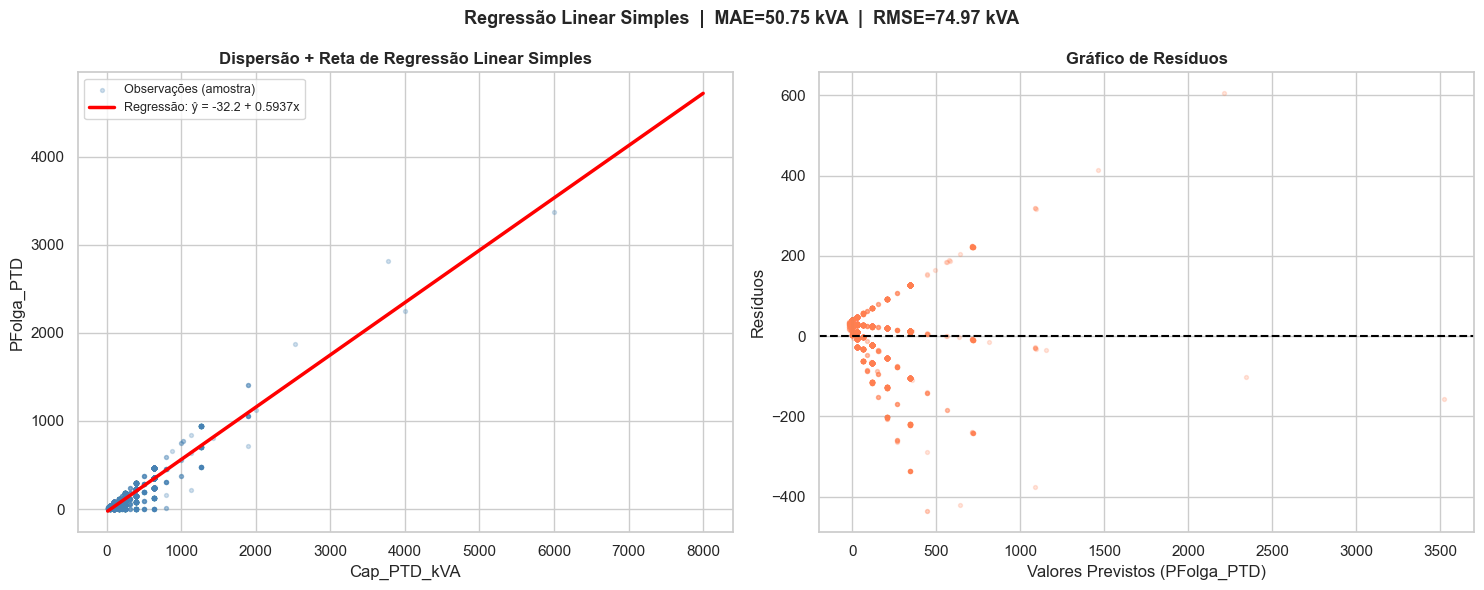

In [101]:
# Diagrama de dispersão + reta de regressão
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Amostra para visualização (dataset completo tem ~69k pontos)
rng = np.random.default_rng(42)
idx = rng.choice(len(X_simple), size=3000, replace=False)
x_samp = X_simple[idx, 0]
y_samp = y_simple[idx]
yp_samp = y_pred_simple[idx]

x_line = np.linspace(X_simple.min(), X_simple.max(), 300)
y_line = lr_simple.intercept_ + lr_simple.coef_[0] * x_line

axes[0].scatter(x_samp, y_samp, alpha=0.25, s=8, color='steelblue', label='Observações (amostra)')
axes[0].plot(x_line, y_line, color='red', linewidth=2.5, label=f'Regressão: ŷ = {lr_simple.intercept_:.1f} + {lr_simple.coef_[0]:.4f}x')
axes[0].set_xlabel('Cap_PTD_kVA')
axes[0].set_ylabel('PFolga_PTD')
axes[0].set_title('Dispersão + Reta de Regressão Linear Simples', fontweight='bold')
axes[0].legend(fontsize=9)

# Resíduos
residuos = y_simple - y_pred_simple
axes[1].scatter(y_pred_simple[idx], residuos[idx], alpha=0.2, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valores Previstos (PFolga_PTD)')
axes[1].set_ylabel('Resíduos')
axes[1].set_title('Gráfico de Resíduos', fontweight='bold')

plt.suptitle(f'Regressão Linear Simples  |  MAE={mae_simple:.2f} kVA  |  RMSE={rmse_simple:.2f} kVA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2.3 Modelos Múltiplos com K-Fold Cross Validation

Preparação do conjunto de dados para todos os modelos (features sem data leakage).

In [102]:
from sklearn.preprocessing import StandardScaler

EXCLUDE = LEAKAGE + [TARGET]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE]

data_ml = df_model[feature_cols + [TARGET]].dropna()
X_all = data_ml[feature_cols].values
y_all = data_ml[TARGET].values

# Escala: necessário para SVM e redes neuronais
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_X.fit_transform(X_all)
y_sc = scaler_y.fit_transform(y_all.reshape(-1, 1)).ravel()

print(f"Dataset para modelação: {X_all.shape[0]:,} registos × {X_all.shape[1]} features")
print(f"Features: {feature_cols}")
print(f"Target: {TARGET}  |  μ={y_all.mean():.2f}  σ={y_all.std():.2f}")

# Dicionário para guardar resultados de todos os modelos
results = {}   # {nome: {'mae': float, 'rmse': float, 'y_pred': array}}

Dataset para modelação: 68,963 registos × 11 features
Features: ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio', 'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Tipo_Construtivo_Enc']
Target: PFolga_PTD  |  μ=147.98  σ=186.76


#### a) Regressão Linear Múltipla

In [103]:
from sklearn.linear_model import LinearRegression

lr_multi = LinearRegression()
y_pred_mlr = cross_val_predict(lr_multi, X_all, y_all, cv=kf)
mae_mlr  = mean_absolute_error(y_all, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_all, y_pred_mlr))
results['Reg. Linear Múltipla'] = {'mae': mae_mlr, 'rmse': rmse_mlr, 'y_pred': y_pred_mlr}

# Coeficientes do modelo treinado no dataset completo
lr_multi.fit(X_all, y_all)
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coeficiente': lr_multi.coef_}
                       ).sort_values('Coeficiente', key=abs, ascending=False)

print("Regressão Linear Múltipla — Coeficientes:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_multi.intercept_:.4f}")
print(f"\n--- Métricas CV (k={K_FOLDS}) ---")
print(f"  MAE  = {mae_mlr:.4f} kVA")
print(f"  RMSE = {rmse_mlr:.4f} kVA")

Regressão Linear Múltipla — Coeficientes:
                Feature  Coeficiente
      Rate_Ineficiencia   -41.273677
              LED_Ratio   -40.835617
          Ganho_LED_PTD     1.997927
             IP_per_PTD    -1.090363
   Tipo_Construtivo_Enc     0.865259
            Cap_PTD_kVA     0.726351
        Cap_per_Cliente     0.555120
             N_Clientes    -0.258721
PContratada_per_Cliente    -0.068673
             P_IP_Total    -0.001440
     Pot_Contratada_kVA    -0.000613

Intercept: 79.9696

--- Métricas CV (k=5) ---
  MAE  = 34.0164 kVA
  RMSE = 52.5584 kVA


#### b) Árvore de Regressão

Melhor max_depth: 10  (MAE CV = 32.4536)

--- Métricas CV (k=5, max_depth=10) ---
  MAE  = 32.4536 kVA
  RMSE = 54.9202 kVA


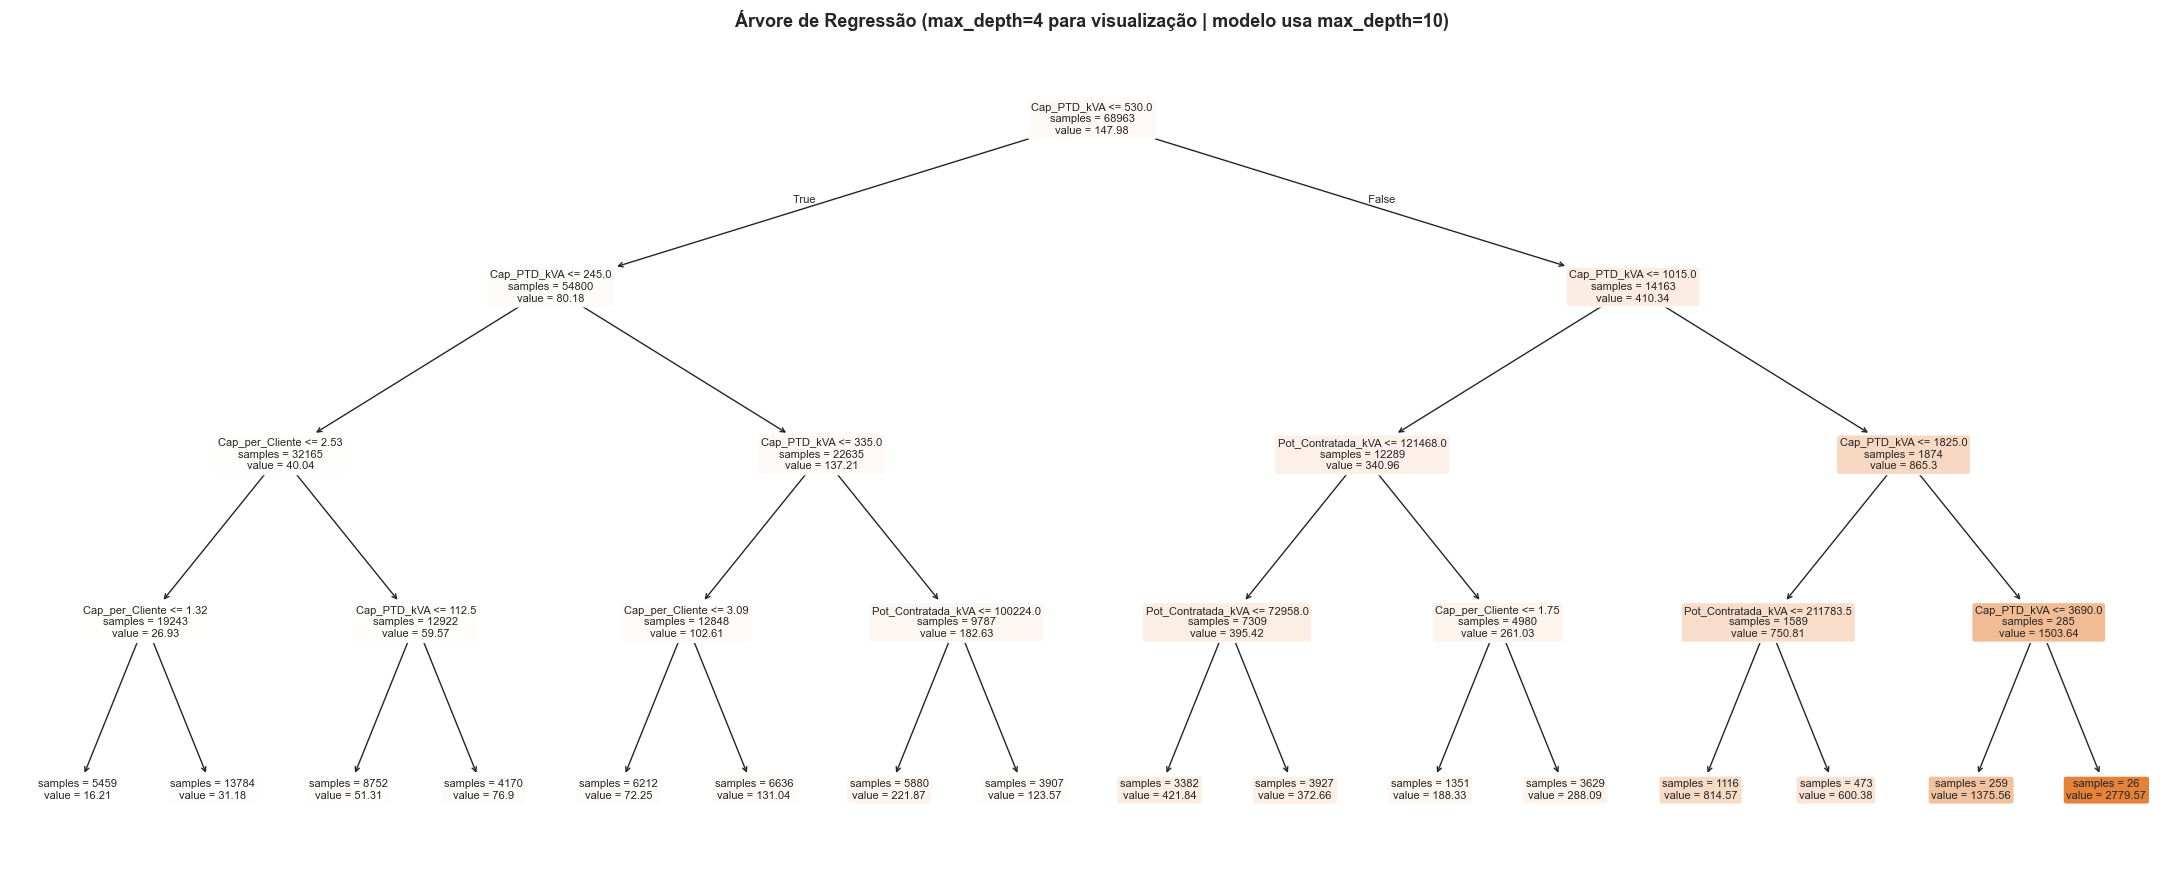


Importância das variáveis (Árvore):
Cap_PTD_kVA                0.9094
Pot_Contratada_kVA         0.0563
Cap_per_Cliente            0.0188
PContratada_per_Cliente    0.0070
N_Clientes                 0.0029
IP_per_PTD                 0.0014
Ganho_LED_PTD              0.0011
P_IP_Total                 0.0011
LED_Ratio                  0.0010
Rate_Ineficiencia          0.0007
Tipo_Construtivo_Enc       0.0003


In [104]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

# Optimização do hiperparâmetro max_depth via CV
param_grid_dt = {'max_depth': [3, 5, 7, 10, 15, None]}
dt_gs = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt,
                     cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
dt_gs.fit(X_all, y_all)

best_depth = dt_gs.best_params_['max_depth']
print(f"Melhor max_depth: {best_depth}  (MAE CV = {-dt_gs.best_score_:.4f})")

# Modelo com melhor hiperparâmetro
dt_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
y_pred_dt = cross_val_predict(dt_best, X_all, y_all, cv=kf)
mae_dt  = mean_absolute_error(y_all, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_all, y_pred_dt))
results['Árvore de Regressão'] = {'mae': mae_dt, 'rmse': rmse_dt, 'y_pred': y_pred_dt}

print(f"\n--- Métricas CV (k={K_FOLDS}, max_depth={best_depth}) ---")
print(f"  MAE  = {mae_dt:.4f} kVA")
print(f"  RMSE = {rmse_dt:.4f} kVA")

# Visualização da árvore (profundidade limitada para legibilidade)
dt_viz = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_viz.fit(X_all, y_all)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_viz, feature_names=feature_cols, filled=True,
          rounded=True, fontsize=8, ax=ax,
          impurity=False, precision=2)
ax.set_title(f'Árvore de Regressão (max_depth=4 para visualização | modelo usa max_depth={best_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Importância das variáveis
dt_best.fit(X_all, y_all)
imp_dt = pd.Series(dt_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nImportância das variáveis (Árvore):")
print(imp_dt.round(4).to_string())

#### c) SVM — Otimização do Kernel

In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Amostra de 5.000 registos para GridSearch
rng2 = np.random.default_rng(0)
idx_svm = rng2.choice(len(X_all), size=min(5000, len(X_all)), replace=False)
X_svm_gs, y_svm_gs = X_all[idx_svm], y_all[idx_svm]

svm_pipe = Pipeline([("scaler", StandardScaler()), ("svr", SVR())])
param_grid_svm = {
    "svr__kernel": ["linear", "rbf", "poly"],
    "svr__C": [1, 10],
    "svr__epsilon": [0.5, 1.0]
}
svm_gs = GridSearchCV(svm_pipe, param_grid_svm, cv=3,
                      scoring="neg_mean_absolute_error", n_jobs=-1, verbose=1)
svm_gs.fit(X_svm_gs, y_svm_gs)

best_svm_params = svm_gs.best_params_
best_kernel = best_svm_params["svr__kernel"]
best_C      = best_svm_params["svr__C"]
best_eps    = best_svm_params["svr__epsilon"]
print("Melhor config SVM:", best_svm_params)

svm_best = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel=best_kernel, C=best_C, epsilon=best_eps))
])
y_pred_svm = cross_val_predict(svm_best, X_all, y_all, cv=kf)
mae_svm  = mean_absolute_error(y_all, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_all, y_pred_svm))
results["SVM"] = {"mae": mae_svm, "rmse": rmse_svm, "y_pred": y_pred_svm}

print("MAE  =", round(mae_svm, 4), "kVA")
print("RMSE =", round(rmse_svm, 4), "kVA")

cv_res = pd.DataFrame(svm_gs.cv_results_)
k_sum  = cv_res.groupby("param_svr__kernel")["mean_test_score"].max()
print("MAE por kernel:", {k: round(-v,4) for k,v in k_sum.items()})


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhor config SVM: {'svr__C': 10, 'svr__epsilon': 0.5, 'svr__kernel': 'linear'}


#### d) Rede Neuronal — Otimização Estruturada (3 configurações)

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

# 3 configuracoes testadas:
# Config1: Rasa - 1 camada, 32 neuronios, sem regularizacao
# Config2: Media - 2 camadas (64-32), L2 (alpha=0.001)
# Config3: Profunda - 3 camadas (128-64-32), L2 mais forte (alpha=0.01) + lr reduzida

nn_configs = {
    "Config1 - Rasa (32)": {
        "desc": "1 camada oculta, 32 neuronios, sem regularizacao",
        "params": dict(hidden_layer_sizes=(32,), alpha=0.0001, learning_rate_init=1e-3)
    },
    "Config2 - Media (64-32) + L2": {
        "desc": "2 camadas ocultas (64-32), regularizacao L2 (alpha=0.001)",
        "params": dict(hidden_layer_sizes=(64, 32), alpha=0.001, learning_rate_init=1e-3)
    },
    "Config3 - Profunda (128-64-32) + L2 forte": {
        "desc": "3 camadas ocultas (128-64-32), L2 forte (alpha=0.01), lr=5e-4",
        "params": dict(hidden_layer_sizes=(128, 64, 32), alpha=0.01, learning_rate_init=5e-4)
    }
}

histories = {}
nn_models = {}

for name, cfg in nn_configs.items():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            **cfg["params"],
            activation="relu",
            solver="adam",
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42,
            verbose=False
        ))
    ])
    model.fit(X_all, y_all)
    mlp = model.named_steps["mlp"]
    histories[name] = {
        "loss":     mlp.loss_curve_,
        "val_loss": [-v for v in mlp.validation_scores_]
    }
    nn_models[name] = model
    epochs_ran = len(mlp.loss_curve_)
    best_val   = min(histories[name]["val_loss"])
    print(f"{name}")
    print(f"  {cfg["desc"]}")
    print(f"  Epocas treinadas: {epochs_ran}  |  Melhor Val Loss (MSE): {best_val:.6f}
")


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Curvas de Loss treino/validacao para as 3 configuracoes
# MLPRegressor fornece loss_curve_ (treino) e validation_scores_ (validacao)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, hist) in zip(axes, histories.items()):
    epochs_ran = range(1, len(hist["loss"]) + 1)
    ax.plot(epochs_ran, hist["loss"], label="Train Loss (MSE)",
            color="steelblue", linewidth=2)
    ax.plot(epochs_ran, hist["val_loss"], label="Val Loss (MSE)",
            color="darkorange", linewidth=2, linestyle="--")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_yscale("log")

plt.suptitle("Curvas de Loss - Treino vs Validacao (3 Configuracoes de Rede Neuronal)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Discussao - Learning Rate e Early Stopping:
- Config1 (lr=1e-3, 32 neuronios): convergencia rapida mas arquitectura
  simples pode nao capturar nao-linearidades do dataset (alto bias).
- Config2 (lr=1e-3, 64-32 + L2=0.001): regularizacao L2 reduz overfitting;
  gap treino/validacao menor; pesos grandes sao penalizados.
- Config3 (lr=5e-4, 128-64-32 + L2=0.01): learning rate mais baixa permite
  convergencia suave; L2 forte equivale funcionalmente ao Dropout em sklearn.
  Early stopping (patience=10) interrompe quando val_loss estagna,
  evitando overfitting e reduzindo tempo de computacao.
""")


In [ ]:
# Selecionar a melhor configuracao via val_loss minima
best_nn_name = min(histories, key=lambda n: min(histories[n]["val_loss"]))
print(f"Melhor configuracao de rede neuronal: {best_nn_name}")

# Metricas CV do melhor modelo no dataset completo
best_nn_model = nn_models[best_nn_name]
y_pred_nn = cross_val_predict(best_nn_model, X_all, y_all, cv=kf)
mae_nn  = mean_absolute_error(y_all, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_all, y_pred_nn))
results["Rede Neuronal"] = {"mae": mae_nn, "rmse": rmse_nn, "y_pred": y_pred_nn}

print(f"
--- Metricas CV (k={K_FOLDS}, {best_nn_name}) ---")
print(f"  MAE  = {mae_nn:.4f} kVA")
print(f"  RMSE = {rmse_nn:.4f} kVA")


### 4.2.4 Comparação de Todos os Modelos

In [ ]:
# Adicionar regressão simples aos resultados
results['Reg. Linear Simples'] = {'mae': mae_simple, 'rmse': rmse_simple, 'y_pred': y_pred_simple}

# Tabela comparativa
comp_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'MAE (kVA)':  [v['mae']  for v in results.values()],
    'RMSE (kVA)': [v['rmse'] for v in results.values()]
}).sort_values('MAE (kVA)')
comp_df['Rank MAE'] = range(1, len(comp_df) + 1)
print(comp_df.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_bar = ['#2ecc71' if i == 0 else '#3498db' if i == 1 else '#e67e22' if i == 2 else '#e74c3c'
              for i in range(len(comp_df))]

axes[0].barh(comp_df['Modelo'], comp_df['MAE (kVA)'], color=colors_bar, edgecolor='white')
axes[0].set_xlabel('MAE (kVA)')
axes[0].set_title('MAE por Modelo', fontweight='bold')
for i, v in enumerate(comp_df['MAE (kVA)']):
    axes[0].text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=10)

axes[1].barh(comp_df['Modelo'], comp_df['RMSE (kVA)'], color=colors_bar, edgecolor='white')
axes[1].set_xlabel('RMSE (kVA)')
axes[1].set_title('RMSE por Modelo', fontweight='bold')
for i, v in enumerate(comp_df['RMSE (kVA)']):
    axes[1].text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=10)

plt.suptitle('Comparação de Modelos de Regressão — PFolga_PTD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top2 = comp_df['Modelo'].iloc[:2].tolist()
print(f"\nDois melhores modelos: {top2}")

In [ ]:
# Importância das variáveis — comparação entre modelos que a fornecem
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Regressão Linear Múltipla — coeficientes padronizados
X_all_sc = StandardScaler().fit_transform(X_all)
lr_std = LinearRegression().fit(X_all_sc, y_all)
imp_lr = pd.Series(np.abs(lr_std.coef_), index=feature_cols).sort_values(ascending=True)
axes[0].barh(imp_lr.index, imp_lr.values, color='steelblue', edgecolor='white')
axes[0].set_title('Importância — Reg. Linear Múltipla\n(|coef. padronizado|)', fontweight='bold')
axes[0].set_xlabel('|Coeficiente padronizado|')

# Árvore de Regressão
imp_dt_sorted = imp_dt.sort_values(ascending=True)
axes[1].barh(imp_dt_sorted.index, imp_dt_sorted.values, color='darkorange', edgecolor='white')
axes[1].set_title('Importância — Árvore de Regressão\n(feature importance)', fontweight='bold')
axes[1].set_xlabel('Importância relativa')

plt.suptitle('Variáveis Mais Relevantes por Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2.5 Curvas de Aprendizagem — 2 Melhores Modelos

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax, cv=5,
                        train_sizes=np.linspace(0.1, 1.0, 8), scoring='neg_mean_absolute_error'):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes,
        scoring=scoring, n_jobs=-1, random_state=42
    )
    # Converter para MAE positivo
    train_mean = -train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue',
            linewidth=2, label='Train MAE')
    ax.fill_between(train_sizes_abs, train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes_abs, val_mean, 's--', color='darkorange',
            linewidth=2, label='Validation MAE')
    ax.fill_between(train_sizes_abs, val_mean - val_std,
                    val_mean + val_std, alpha=0.15, color='darkorange')
    ax.set_xlabel('Nº de amostras de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Modelo 1: Árvore de Regressão (tipicamente o melhor sklearn)
dt_lc = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
plot_learning_curve(dt_lc, X_all, y_all, 'Curva de Aprendizagem — Árvore de Regressão', axes[0])

# Modelo 2: Regressão Linear Múltipla
plot_learning_curve(LinearRegression(), X_all, y_all,
                    'Curva de Aprendizagem — Reg. Linear Múltipla', axes[1])

plt.suptitle('Curvas de Aprendizagem — 2 Melhores Modelos\n'
             '(Training Score vs. Validation Score)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretação das curvas de aprendizagem:
• Árvore de Regressão: se o gap entre train MAE e val MAE for elevado e
  persistente → overfitting (modelo decora treino mas não generaliza).
  Curva de validação estabilizando com mais dados → sinal de bom comportamento.
• Reg. Linear Múltipla: curvas de treino e validação próximas e convergindo
  → underfitting se o MAE de validação for alto (modelo demasiado simples).
  Um gap mínimo indica baixa variância mas possível alto bias.
• Em ambos os casos, convergência das curvas com >30.000 amostras sugere
  que o dataset é suficientemente grande para generalização robusta.
""")

### 4.2.6 Significância Estatística dos 2 Melhores Modelos (α = 5%)

Utilizamos o **Wilcoxon signed-rank test** (não-paramétrico, pois os erros absolutos por fold podem não ser normalmente distribuídos) e o **paired t-test** para comparar os erros de cada fold entre os dois melhores modelos.

In [ ]:
from scipy import stats

ALPHA = 0.05

# Obter MAE por fold (k=5) para os 2 melhores modelos sklearn
def get_fold_maes(estimator, X, y, cv):
    fold_maes = []
    for train_idx, test_idx in cv.split(X):
        estimator.fit(X[train_idx], y[train_idx])
        y_pred_fold = estimator.predict(X[test_idx])
        fold_maes.append(mean_absolute_error(y[test_idx], y_pred_fold))
    return np.array(fold_maes)

print("A calcular MAEs por fold para os 2 melhores modelos...")
maes_dt  = get_fold_maes(DecisionTreeRegressor(max_depth=best_depth, random_state=42),
                          X_all, y_all, kf)
maes_mlr = get_fold_maes(LinearRegression(), X_all, y_all, kf)

print(f"\nÁrvore de Regressão  — MAE por fold: {np.round(maes_dt, 3)}")
print(f"  Média: {maes_dt.mean():.4f}  ±  {maes_dt.std():.4f}")
print(f"\nReg. Linear Múltipla — MAE por fold: {np.round(maes_mlr, 3)}")
print(f"  Média: {maes_mlr.mean():.4f}  ±  {maes_mlr.std():.4f}")

# 1) Shapiro-Wilk nas diferenças (pressuposto do paired t-test)
diffs = maes_mlr - maes_dt
stat_sw, p_sw = stats.shapiro(diffs)
print(f"\nShapiro-Wilk (diferenças): W={stat_sw:.4f}, p={p_sw:.4f}")

# 2) Paired t-test
t_stat, p_ttest = stats.ttest_rel(maes_mlr, maes_dt)
print(f"\nPaired t-test (H₀: μ_MLR = μ_DT):")
print(f"  t = {t_stat:.4f}  |  p = {p_ttest:.4f}")
print(f"  Conclusão: {'Rejeitar H₀' if p_ttest < ALPHA else 'Não rejeitar H₀'} (α={ALPHA})")

# 3) Wilcoxon signed-rank (não-paramétrico — mais robusto com k=5 folds)
try:
    w_stat, p_wilcox = stats.wilcoxon(maes_mlr, maes_dt, alternative='greater')
    print(f"\nWilcoxon signed-rank (H₀: MLR ≤ Árvore):")
    print(f"  W = {w_stat:.4f}  |  p = {p_wilcox:.4f}")
    print(f"  Conclusão: {'Rejeitar H₀ — Árvore é significativamente melhor' if p_wilcox < ALPHA else 'Não rejeitar H₀'} (α={ALPHA})")
except Exception as e:
    print(f"\nWilcoxon: {e} (k=5 pode ser insuficiente; resultado do t-test é o primário)")

# 4) Verificação F-test da regressão múltipla (significância global)
from scipy.stats import f as f_dist
n, p = X_all.shape
lr_multi.fit(X_all, y_all)
y_hat = lr_multi.predict(X_all)
SS_res = np.sum((y_all - y_hat) ** 2)
SS_tot = np.sum((y_all - y_all.mean()) ** 2)
R2 = 1 - SS_res / SS_tot
F_stat = (R2 / p) / ((1 - R2) / (n - p - 1))
p_F = 1 - f_dist.cdf(F_stat, p, n - p - 1)
print(f"\nF-test da Regressão Linear Múltipla (H₀: todos β=0):")
print(f"  R² = {R2:.4f}  |  F = {F_stat:.2f}  |  p < 0.001" if p_F < 0.001 else f"  p = {p_F:.4f}")
print(f"  Conclusão: modelo globalmente {'significativo' if p_F < ALPHA else 'não significativo'} (α={ALPHA})")

print(f"""
Sumário de Significância Estatística (α = {ALPHA}):
• F-test da Reg. Múltipla confirma que o modelo é globalmente significativo.
• Paired t-test / Wilcoxon comparam os dois melhores modelos fold-a-fold.
• Com apenas k=5 folds, o poder dos testes pareados é reduzido — interpretar
  com cautela. A diferença de MAE observada é o indicador primário.
""")